## SSL 30 Epoch Run
### Self Supervised Model Pretraining

Same SSL encoder as **04_SSL_Model.ipynb** trained for **30 epochs** instead of 15. 

Input window: **32 messages** 

Features: 

- **CAN_ID**: categorical embedding 
- **b0-b7, DLC, Δt**: numeric features
- **Δt** is log transformed before standarization 

Embeddings are saved as **X_cnn_30.npy** for the comparison in **05_XGBoost_Evaluation.ipynb**.

## 1. Setup 

### Imports

In [1]:
import numpy as np 
from pathlib import Path 
import torch 
import torch.nn as nn 
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, ConcatDataset 
from tqdm import tqdm

### Hyperparameters & paths

In [2]:
SEED = 42 # Random seed for reproducibility
torch.manual_seed(SEED)

WINDOW_SIZE = 32
MASK_PROPORTION = 0.30 

BATCH_SIZE = 128 
NUM_EPOCHS = 30 
LEARNING_RATE = 0.0003 

CAN_EMBEDDING_DIM = 8 
DT_SCALE = 1_000_000.0  

BENIGN_WINDOWS = Path("..") / "Data" / "Benign_Windows"
ATTACK_WINDOWS = Path("..") / "Data" / "Attack_Windows"
MODEL_FOLDER = Path("models")
NPY_DIR = Path("embeddings")

device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

print("Device:", device)



Device: mps


## 2. Data Loading 

### Benign Training Windows

In [3]:
benign_train_paths = sorted(BENIGN_WINDOWS.glob("**/*_train.pt"))
benign_test_paths = sorted(BENIGN_WINDOWS.glob("**/*_test.pt"))

benign_train_windows = []

for path in benign_train_paths: 
    data = torch.load(path, map_location="cpu", weights_only=False)
    benign_train_windows.append(data["features"])
    
print("Training Files:", len(benign_train_windows))
print("Test Files:", len(benign_test_paths))
print("First Training Tensor:", benign_train_windows[0].shape)

Training Files: 3
Test Files: 3
First Training Tensor: torch.Size([429074, 32, 11])


## 3. Feature Preprocessing

### 3.1 CAN ID Vocabulary 

In [4]:
can_id_vocabulary = set()

for tensor in benign_train_windows:
    ids_in_file = torch.unique(tensor[:, :, 0].long()).tolist()
    for can_id in ids_in_file:
        can_id_vocabulary.add(int(can_id))

can_id_vocabulary = sorted(can_id_vocabulary)

can_id_to_index = {}
for index, can_id in enumerate(can_id_vocabulary):
    can_id_to_index[can_id] = index

NUM_CAN_IDS = len(can_id_vocabulary)
UNK_ID = NUM_CAN_IDS
MASK_ID = NUM_CAN_IDS + 1

print("Known benign CAN IDs:", NUM_CAN_IDS)
print("UNK_ID:", UNK_ID)
print("MASK_ID:", MASK_ID)

Known benign CAN IDs: 56
UNK_ID: 56
MASK_ID: 57


In [5]:
for can_id, index in can_id_to_index.items():
    print(can_id, "->", index)

127 -> 0
304 -> 1
320 -> 2
339 -> 3
352 -> 4
356 -> 5
544 -> 6
593 -> 7
688 -> 8
832 -> 9
881 -> 10
882 -> 11
897 -> 12
902 -> 13
903 -> 14
905 -> 15
909 -> 16
916 -> 17
1040 -> 18
1042 -> 19
1056 -> 20
1057 -> 21
1078 -> 22
1136 -> 23
1151 -> 24
1157 -> 25
1168 -> 26
1173 -> 27
1186 -> 28
1191 -> 29
1225 -> 30
1265 -> 31
1280 -> 32
1287 -> 33
1290 -> 34
1291 -> 35
1292 -> 36
1294 -> 37
1312 -> 38
1322 -> 39
1342 -> 40
1345 -> 41
1348 -> 42
1355 -> 43
1363 -> 44
1369 -> 45
1407 -> 46
1426 -> 47
1427 -> 48
1429 -> 49
1430 -> 50
1456 -> 51
1470 -> 52
1473 -> 53
1507 -> 54
1535 -> 55


In [6]:
def convert_can_ids(raw_can_ids):
    # Convert CAN IDs to embedding indexes 
    can_id_indexes = []
    # Get the index of the CAN ID in the training vocabulary 
    for can_id in raw_can_ids.tolist():
        # If the CAN ID is not in the training vocabulary, use UNK_ID
        index = can_id_to_index.get(can_id, UNK_ID)
        can_id_indexes.append(index)
        
    # torch.long is used to store the indexes as integers 
    return torch.tensor(can_id_indexes, dtype=torch.long)

### 3.2 Numeric Features 

In [7]:
# Transform Δt 
def transform_delta(delta): 
    delta = delta.float()
    delta_microseconds = delta * DT_SCALE
    transformed_delta = torch.log1p(delta_microseconds)
    return transformed_delta

In [8]:
scaler = StandardScaler()
all_windows = torch.cat(benign_train_windows, dim=0)
features = all_windows[:, :, 1:].float().clone()
# Transform the Δt column 
features[:, :, -1] = transform_delta(features[:, :, -1])
# Fit the scaler
scaler.fit(features.reshape(-1, 10).numpy())

# Mean
training_mean = torch.tensor(scaler.mean_, dtype=torch.float32)
# Standard deviation 
training_std = torch.tensor(scaler.scale_, dtype=torch.float32)

In [9]:
feature_names = [
    "b0", "b1", "b2", "b3",
    "b4", "b5", "b6", "b7",
    "DLC", "log_dt"
]

for i in range(len(feature_names)):

    print(
        feature_names[i],
        "| mean:", round(training_mean[i].item(), 4),
        "| std:", round(training_std[i].item(), 4)
    )

b0 | mean: 58.0659 | std: 77.6297
b1 | mean: 60.4033 | std: 77.4116
b2 | mean: 48.1177 | std: 72.989
b3 | mean: 61.4968 | std: 84.7441
b4 | mean: 47.9577 | std: 78.4898
b5 | mean: 53.5674 | std: 83.4639
b6 | mean: 33.8867 | std: 63.0744
b7 | mean: 53.2536 | std: 72.7697
DLC | mean: 7.303 | std: 1.4544
log_dt | mean: 2.6932 | std: 2.9822


In [10]:
def standardise_features(window):
    features = window[:, 1:].float().clone()
    # Apply the same transformation established earlier 
    features[:, -1] = transform_delta(features[:, -1])
    # Standarize the features
    standardised_features = (features - training_mean) / training_std 
    return standardised_features
    

### 3.3 Dataset & DataLoader 

In [11]:
class BenignWindowDataset(Dataset): 
    
    def __init__(self, windows): 
        self.windows = windows
        
    def __len__(self): 
        return len(self.windows)
    
    def __getitem__(self, index): 
        
        window = self.windows[index]
        
        # Parse the CAN ID column 
        raw_can_ids = window[:, 0].long()
        # Convert CAN IDs to embedding indexes 
        can_id_indexes = convert_can_ids(raw_can_ids)
        
        # Prepare the 10 numerical features for that window 
        standardised_features = standardise_features(window)
        
        # Return the CAN ID indexes and the standardised features 
        return can_id_indexes, standardised_features     

In [12]:
training_datasets = []

for file_windows in benign_train_windows:
    training_datasets.append(BenignWindowDataset(file_windows))

train_dataset = ConcatDataset(training_datasets)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Total training windows:", len(train_dataset))
print(f"Batches per epoch: {len(train_loader)}")

Total training windows: 1335237
Batches per epoch: 10432


## 4. Model Architecture 

### 4.1 CNN Encoder 

Three Conv1d layers (dilation 1, 2, 4; padding 1, 2, 4). Shape: (128, 18, 32) → (128, 64, 32).

In [13]:
class CNNEncoder(nn.Module): 
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv1d(
            in_channels=18, 
            out_channels=64, 
            kernel_size=3, 
            padding=1,
            dilation=1
        )
        
        self.conv2 = nn.Conv1d(
            in_channels=64, 
            out_channels=64, 
            kernel_size=3, 
            padding=2,
            dilation=2
        )
        
        self.conv3 = nn.Conv1d(
            in_channels=64, 
            out_channels=64, 
            kernel_size=3, 
            padding=4, 
            dilation=4
        )
        
        self.relu = nn.ReLU()
        
    def forward(self, x): 
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        
        return x

### 4.2 Reconstruction Heads 

In [14]:
class CANIDReconHead(nn.Module): 
    
    def __init__(self): 
        
        super().__init__()
        
        self.can_id_prediction = nn.Conv1d(
            in_channels=64, 
            out_channels=56, 
            kernel_size=1 # 1D conv, 1D output
        )
        
    def forward(self, encoded_features): 
        # Conv1d: (batch, 64, 32) -> (batch, 56, 32)
        can_id_predictions = self.can_id_prediction(encoded_features)
        # CrossEntropy wants (batch, sequence, classes)
        can_id_predictions = can_id_predictions.permute(0, 2, 1)
        
        return can_id_predictions # logits 
    
# 56 scores per position; the largest score = predicted CAN ID

In [15]:
class NumericReconHead(nn.Module): 
    
    def __init__(self): 
        
        super().__init__()
        
        self.feature_predictions = nn.Conv1d(
            in_channels=64,  
            out_channels=10,  
            kernel_size=1 # 1D conv, 1D output
        )
        
    def forward(self, encoded_features): 
        # Conv1d: (batch, 64, 32) -> (batch, 10, 32)
        feature_predictions = self.feature_predictions(encoded_features)
        feature_predictions = feature_predictions.permute(0,2,1) # (128, 10, 32) to (128, 32, 10) for MSE Loss
        
        return feature_predictions 
    

### 4.3 Complete SSL Model 

In [ ]:
class SSLModel(nn.Module): 
    
    def __init__(self): 
        super().__init__()
        
        # CAN ID Embedding Layer
        self.can_embedding = nn.Embedding(num_embeddings=NUM_CAN_IDS + 2, embedding_dim=CAN_EMBEDDING_DIM) #56 known + 2 special tokens and 8 dim embedding
        # CNN Encoder 
        self.encoder = CNNEncoder()
        # CAN ID Reconstruction Head
        self.can_id_head = CANIDReconHead()
        # Numerical Features Reconstruction Head
        self.numerical_head = NumericReconHead()
    
    # Forward pass which takes masked CAN IDs and features as input
    def forward(self, masked_can_ids, masked_features):   
        # Concatenate CAN IDs and features
        embedding_representation = torch.cat((self.can_embedding(masked_can_ids), masked_features), dim=2)
        # Flip the dimensions to match the expected input shape for the CNN
        cnn_input = embedding_representation.permute(0,2,1)
        # Pass through the CNN encoder
        encoded_features = self.encoder(cnn_input)
        # CAN ID Reconstruction
        can_id_predictions = self.can_id_head(encoded_features) # (batch,32,56)
        # Numerical Features Reconstruction
        feature_predictions = self.numerical_head(encoded_features) # (batch,32,10)
        return can_id_predictions, feature_predictions, encoded_features
    
ssl_model = SSLModel().to(device)
print(ssl_model)

SSLModel(
  (can_embedding): Embedding(58, 8)
  (encoder): CNNEncoder(
    (conv1): Conv1d(18, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (relu): ReLU()
  )
  (can_id_head): CANIDReconHead(
    (can_id_prediction): Conv1d(64, 56, kernel_size=(1,), stride=(1,))
  )
  (numerical_head): NumericReconHead(
    (feature_predictions): Conv1d(64, 10, kernel_size=(1,), stride=(1,))
  )
)


## 5. SSL Training

### 5.1 Masking 

In [ ]:
positions_to_mask = round(WINDOW_SIZE * MASK_PROPORTION)

def mask_batch(can_id_batch, feature_batch):
    # Create a boolean mask for each window in the current batch
    window_mask = torch.zeros((len(can_id_batch), WINDOW_SIZE), dtype=torch.bool, device=device)
    
    # Loop through each window in the batch 
    for i in range(len(can_id_batch)):
        # Randomly select positions to mask 
        positions = torch.randperm(WINDOW_SIZE, device=device)[:positions_to_mask]
        window_mask[i, positions] = True
    
    # Make a copy of the CAN IDs and Features     
    masked_can_ids = can_id_batch.clone()
    masked_features = feature_batch.clone()
    
    # Mask the selected positions 
    masked_can_ids[window_mask] = MASK_ID
    masked_features[window_mask] = 0
    
    return masked_can_ids, masked_features, window_mask       

### 5.2 Loss

In [ ]:
can_loss_function = nn.CrossEntropyLoss()
feature_loss_function = nn.MSELoss()

def calculate_loss(can_id_batch, feature_batch): 
    # Mask 10 message positions in each window 
    masked_can_ids, masked_features, window_mask = mask_batch(can_id_batch, feature_batch)
    
    # Reconstruct the CAN ID and the numerical features from the masked inputs 
    can_predictions, feature_predictions, _ = ssl_model(masked_can_ids, masked_features)
    
    # Compare CAN ID predictions to the original IDs only at the masked positions 
    can_loss = can_loss_function(can_predictions[window_mask], can_id_batch[window_mask])
    # Compare the predicted numerical features to the original features only at the masked positions 
    feature_loss = feature_loss_function(feature_predictions[window_mask], feature_batch[window_mask])
    
    # Combine both reconstruction losses 
    total_loss = 1.0 * can_loss + 1.0 * feature_loss
    
    # Return the individual losses and the total loss for later analysis 
    return can_loss, feature_loss, total_loss

### 5.3 Training Loop 

In [ ]:
# Initialise the optimizer 
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=LEARNING_RATE)
# Store the average loss from each epoch 
epoch_can_id_loss = []
epoch_feature_loss = []
epoch_total_loss = []

ssl_model.train()

for epoch in range(NUM_EPOCHS):

    # Counters that add together the losses from every batch in that epoch 
    can_loss_sum = 0
    feature_loss_sum = 0
    total_loss_sum = 0

    # Train on every batch
    for can_id_batch, feature_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"):
        
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)

        can_id_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)

        # clear gradients from previous batch   
        optimizer.zero_grad() 
        
        # Backpropagation
        total_loss.backward() 
        
        # update the model parameters using the gradients 
        optimizer.step() 

        # Adds this batch's losses to the epoch totals 
        # .item() converts the tensor to a python number 
        can_loss_sum += can_id_loss.item()
        feature_loss_sum += feature_loss.item()
        total_loss_sum += total_loss.item()
        
    # Store the average loss from each epoch 
    epoch_can_id_loss.append(can_loss_sum / len(train_loader))
    epoch_feature_loss.append(feature_loss_sum / len(train_loader))
    epoch_total_loss.append(total_loss_sum / len(train_loader))

Epoch 30/30: 100%|██████████| 10432/10432 [04:01<00:00, 43.20it/s]


### 5.4 Save Model  & Load Model 

Save the trained weights so we do not need to retrain every time.  
Later we reload the same file for evaluation and for the encoder feature extraction.

In [ ]:
torch.save(ssl_model.state_dict(), MODEL_FOLDER / "ssl_model_cnn_30.pth")

In [19]:
ssl_model = SSLModel().to(device)
ssl_model.load_state_dict(torch.load(MODEL_FOLDER / "ssl_model_cnn_30.pth"))

<All keys matched successfully>

## 6. Evaluation

Evaluate the trained model’s reconstruction quality using the three SSL losses (CAN ID, numeric features, and total) on the training data.

### 6.1 Train Reconstruction Loss

In [44]:
ssl_model.eval() # Model in evaluation mode
 
# Average losses for the entire training set 
train_can_loss = 0   
train_feature_loss = 0
train_total_loss = 0

with torch.no_grad():

    for can_id_batch, feature_batch in tqdm(train_loader, desc="Training loss check"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)

        can_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch) # Calculate the loss for the batch 

        train_can_loss += can_loss.item() 
        train_feature_loss += feature_loss.item()
        train_total_loss += total_loss.item()


Training loss check: 100%|██████████| 10432/10432 [03:28<00:00, 50.08it/s]


In [45]:
train_can_loss = train_can_loss / len(train_loader)
train_feature_loss = train_feature_loss / len(train_loader)
train_total_loss = train_total_loss / len(train_loader)

print("CAN ID loss:", train_can_loss)
print("Feature loss:", train_feature_loss)
print("Total loss:", train_total_loss)

CAN ID loss: 0.6567496652914885
Feature loss: 0.48099441295261125
Total loss: 1.1377440784869293


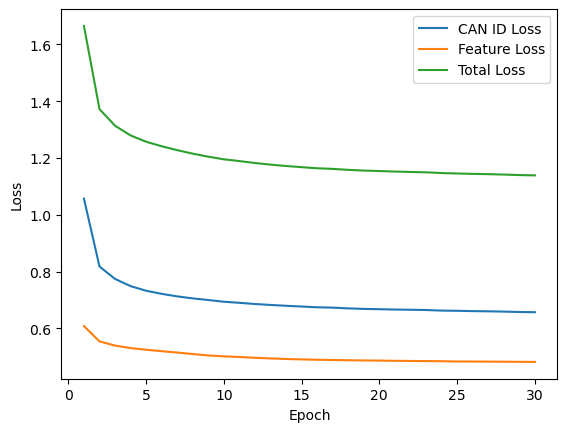

In [46]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.plot(epochs, epoch_can_id_loss, label="CAN ID Loss")
plt.plot(epochs, epoch_feature_loss, label="Feature Loss")
plt.plot(epochs, epoch_total_loss, label="Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 6.2 Test Dataset 

In [20]:
#### Load the test data 
test_windows = []
for pt_file in benign_test_paths:
    data = torch.load(pt_file, map_location="cpu", weights_only=False)
    test_windows.append(data["features"])
print("Test Files:", len(benign_test_paths))
print("First Test Tensor:", test_windows[0].shape)

Test Files: 3
First Test Tensor: torch.Size([183888, 32, 11])


We test the data the same way we trained it with the exception of the shuffle=False for consistent batch order. 

In [21]:
# Test dataset and dataloader 

# store one dataset for each test file 
test_datasets = []

for file_windows in test_windows:
    test_datasets.append(BenignWindowDataset(file_windows))

test_dataset = ConcatDataset(test_datasets)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### 6.3 Test Reconstruction Loss

In [49]:
ssl_model.eval()

test_can_loss = 0 
test_feature_loss = 0 
test_total_loss = 0 

with torch.no_grad():
    
    for can_id_batch, feature_batch in tqdm(test_loader, desc="Testing"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)
        
        can_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)
        
        test_can_loss += can_loss.item()
        test_feature_loss += feature_loss.item()
        test_total_loss += total_loss.item()

Testing: 100%|██████████| 4471/4471 [01:28<00:00, 50.66it/s]


In [50]:
test_can_loss = test_can_loss / len(test_loader)
test_feature_loss = test_feature_loss / len(test_loader)
test_total_loss = test_total_loss / len(test_loader)

print("Test CAN ID loss:", test_can_loss)
print("Test feature loss:", test_feature_loss)
print("Test total loss:", test_total_loss)

Test CAN ID loss: 0.7291289450631155
Test feature loss: 0.49274049298364936
Test total loss: 1.2218694370935705


## 7. Encoder Feature Extraction

In [22]:
def extract_encoder(data_loader): 
    all_features = []
    
    with torch.no_grad(): 
        for can_ids, features in tqdm(data_loader, desc="Extracting features"): 
            can_ids = can_ids.to(device)
            features = features.to(device)
            
            # Runs the model on the batch on unmasked data 
            _, _, encoded_features = ssl_model(can_ids, features)
            
            # Encoded features are [batch_size, 64, 32]
            # We want to reduce them to [batch_size, 192] 
            mean_features = encoded_features.mean(dim=2)
            max_features = encoded_features.max(dim=2).values
            std_features = encoded_features.std(dim=2)            
            
            window_features = torch.cat([mean_features, max_features, std_features], dim=1)
            
            all_features.append(window_features.cpu())
        
    return torch.cat(all_features)

### Multiclass Classification with XGBoost

### 8.1 Attack Window Split

In [24]:
GAP_WINDOWS = 15

def split_attack_windows(file_name): 
    
    # Load the attack window files
    data = torch.load(ATTACK_WINDOWS / f"{file_name}.pt", map_location="cpu", weights_only=False)
    
    # Extract the features from the file 
    windows = data["features"]
    labels = data["labels"]
    
    # Split the windows into train and test sets based on the 70% and 30% split 
    split_index = int(len(windows) * 0.70)
    
    # Split the train window from the beginnign of the file to the split index = 70% 
    train_windows = windows[:split_index]
    train_labels = labels[:split_index]
    
    # Split the rest of the window from the split index + 15 window gap = last part of the window 
    # which corresponds to the 30% of the file 
    test_windows = windows[split_index + GAP_WINDOWS:]
    test_labels = labels[split_index + GAP_WINDOWS:]
    
    return train_windows, train_labels, test_windows, test_labels

In [ ]:
#  Use the same Dataset preprocessing expected by the trained encoder
def windows_to_encoder_features(windows): 
    dataset = BenignWindowDataset(windows)
    data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    return extract_encoder(data_loader)

### 8.2 Extract Attack Encoder Features

For each attack file:
1. Split the windows chronologically into train and test, with a 15-window gap.
2. Extract the 192-dimensional encoder features for both sets.

We process one attack type at a time, then concatenate everything into the final **X_train / X_test** datasets.

In [ ]:
train_feature_sets = []
test_feature_sets = []

train_label_sets = []
test_label_sets = []

attack_files = [
    ATTACK_WINDOWS / "DoS_attack.pt",
    ATTACK_WINDOWS / "Steering_angle_attack.pt",
    ATTACK_WINDOWS / "Fuzzing_random_IDs.pt",
    ATTACK_WINDOWS / "EMS_replay_attack.pt",
]

for file_path in attack_files:
    # Extract the file name from the path 
    file_name = file_path.stem

    # Split the attack windows into train and test sets 
    train_windows, train_window_labels, test_windows, test_window_labels = split_attack_windows(file_name)

    # Extract the encoder features 
    train_encoder_features = windows_to_encoder_features(train_windows)
    test_encoder_features = windows_to_encoder_features(test_windows)
    
    # Append the features and labels to the lists 
    train_feature_sets.append(train_encoder_features)
    test_feature_sets.append(test_encoder_features)
    train_label_sets.append(train_window_labels)
    test_label_sets.append(test_window_labels)

    print(file_name, "| Train:", len(train_encoder_features), "| Test:", len(test_encoder_features))

Extracting features: 100%|██████████| 207/207 [00:00<00:00, 215.68it/s]


DoS_attack | Train: 61665 | Test: 26414


Extracting features: 100%|██████████| 148/148 [00:00<00:00, 232.86it/s]


Steering_angle_attack | Train: 44177 | Test: 18918


Extracting features: 100%|██████████| 283/283 [00:01<00:00, 249.86it/s]


Fuzzing_random_IDs | Train: 84513 | Test: 36205


Extracting features: 100%|██████████| 151/151 [00:00<00:00, 246.25it/s]

EMS_replay_attack | Train: 45075 | Test: 19303


### 8.3 XGBoost Numpy Datasets
- X_train / X_test → 192 encoder features for each window
- y_train / y_test → attack label for each window

Each window therefore has 192 input features and one class label.

In [27]:
# Concatenate the features and labels 
X_train = torch.cat(train_feature_sets)
y_train = torch.cat(train_label_sets)

# Concatenate the test features and labels 
X_test = torch.cat(test_feature_sets)
y_test = torch.cat(test_label_sets)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([235430, 192])
y_train: torch.Size([235430])
X_test: torch.Size([100840, 192])
y_test: torch.Size([100840])


In [28]:
for class_id in range(4):
    print(
        f"Class {class_id}: "
        f"Train {(y_train == class_id).sum().item()}, "
        f"Test {(y_test == class_id).sum().item()}"
    )

X_train = X_train.numpy()
y_train = y_train.numpy()
X_test = X_test.numpy()
y_test = y_test.numpy()

print(np.isnan(X_train).any())    

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

np.save(NPY_DIR / "X_train_cnn_30.npy", X_train)
np.save(NPY_DIR / "y_train_cnn_30.npy", y_train)
np.save(NPY_DIR / "X_test_cnn_30.npy", X_test)
np.save(NPY_DIR / "y_test_cnn_30.npy", y_test)

print("Saved to:", NPY_DIR)

Class 0: Train 61665, Test 26414
Class 1: Train 44177, Test 18918
Class 2: Train 84513, Test 36205
Class 3: Train 45075, Test 19303
False
X_train: (235430, 192) | X_test: (100840, 192)
Saved to: embeddings
